# Survival Analysis 

## Purpose
This notebook evaluates the relationship between tumor mutational burden (TMB) and overall survival in pediatric rhabdomyosarcoma patients. Kaplan–Meier survival curves are generated to compare patients with low and high TMB, and a log-rank test is used to determine whether the survival distributions differ significantly.

Because some patients contributed multiple tumor samples, the primary analysis uses the patient-level dataset created in the previous notebook. Additional analyses compare different TMB aggregation and grouping methods to evaluate the stability of the results

## Objectives 
* Load the patient-level survival dataset.
* Verify that survival times and survival-status values are valid.
* Create a binary event variable.
* Divide patients into low- and high-TMB groups.
* Generate Kaplan–Meier survival curves.
* Perform a log-rank test.
* Calculate median survival for each TMB group.
* Compare alternative TMB cutoffs and aggregation methods.
* Export survival-analysis results and figures

# Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Define Project Paths

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA_FILE = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "patient_level_mean.tsv"
)

RESULTS_DIR = PROJECT_DIR / "results" / "survival"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Data file:", DATA_FILE)
print("File exists:", DATA_FILE.exists())
print("Results directory:", RESULTS_DIR)

Data file: /users/PAS3421/emmafischels/Capstone/data/processed/patient_level_mean.tsv
File exists: True
Results directory: /users/PAS3421/emmafischels/Capstone/results/survival


# Load the patient-level dataset

In [3]:
patient_df = pd.read_csv(
    DATA_FILE,
    sep="\t"
)

print("Rows:", patient_df.shape[0])
print("Columns:", patient_df.shape[1])

patient_df.head()

Rows: 20
Columns: 4


,Patient ID,TMB (nonsynonymous),Overall Survival (Months),Overall Survival Status
0,P-0006113,0.921709,37.085,1:DECEASED
1,P-0013120,0.000000,31.890,1:DECEASED
2,P-0018770,1.729396,32.449,1:DECEASED
3,P-0019531,0.432349,69.008,0:LIVING
4,P-0022317,0.000000,5.688,1:DECEASED


# Confirm that each patient appears once

In [4]:
print(
    "Unique patients:",
    patient_df["Patient ID"].nunique()
)

print(
    "Total rows:",
    len(patient_df)
)

duplicate_patients = patient_df[
    patient_df["Patient ID"].duplicated(
        keep=False
    )
]

duplicate_patients

Unique patients: 20
Total rows: 20


,Patient ID,TMB (nonsynonymous),Overall Survival (Months),Overall Survival Status


# Inspect survival variables

In [5]:
survival_columns = [
    "Patient ID",
    "TMB (nonsynonymous)",
    "Overall Survival (Months)",
    "Overall Survival Status"
]

patient_df[survival_columns].head()

,Patient ID,TMB (nonsynonymous),Overall Survival (Months),Overall Survival Status
0,P-0006113,0.921709,37.085,1:DECEASED
1,P-0013120,0.000000,31.890,1:DECEASED
2,P-0018770,1.729396,32.449,1:DECEASED
3,P-0019531,0.432349,69.008,0:LIVING
4,P-0022317,0.000000,5.688,1:DECEASED


In [6]:
# Examine the survival-status categories 

patient_df[
    "Overall Survival Status"
].value_counts(
    dropna=False
)

Overall Survival Status
1:DECEASED    10
0:LIVING       9
NaN            1
Name: count, dtype: int64

# Convert survival status into an event variable 

In survival analysis:

* 1 means the patient experienced the event, which is death.
* 0 means the patient was censored, meaning the patient was alive at the last recorded follow-up.

In [7]:
status_map = {
    "1:DECEASED": 1,
    "0:LIVING": 0
}

patient_df["Event"] = (
    patient_df[
        "Overall Survival Status"
    ]
    .map(status_map)
)

In [8]:
# Check the conversion 

patient_df[
    [
        "Overall Survival Status",
        "Event"
    ]
].drop_duplicates()

,Overall Survival Status,Event
0,1:DECEASED,1.0
3,0:LIVING,0.0
5,NaN,NaN


# Create a clean survival dataset 

In [9]:
survival_df = patient_df[
    [
        "Patient ID",
        "TMB (nonsynonymous)",
        "Overall Survival (Months)",
        "Overall Survival Status",
        "Event"
    ]
].copy()

In [10]:
# Convert the main variables to numeric values

survival_df[
    "TMB (nonsynonymous)"
] = pd.to_numeric(
    survival_df[
        "TMB (nonsynonymous)"
    ],
    errors="coerce"
)

survival_df[
    "Overall Survival (Months)"
] = pd.to_numeric(
    survival_df[
        "Overall Survival (Months)"
    ],
    errors="coerce"
)

In [11]:
# Remove observations without the information required for survival analysis 

survival_df = survival_df.dropna(
    subset=[
        "TMB (nonsynonymous)",
        "Overall Survival (Months)",
        "Event"
    ]
).copy()

survival_df["Event"] = (
    survival_df["Event"]
    .astype(int)
)

print(
    "Patients available for survival analysis:",
    len(survival_df)
)

Patients available for survival analysis: 19


# Check for invalid survival times 

In [12]:
invalid_survival_times = survival_df[
    survival_df[
        "Overall Survival (Months)"
    ] < 0
]

invalid_survival_times

,Patient ID,TMB (nonsynonymous),Overall Survival (Months),Overall Survival Status,Event


In [13]:
# Check the distribution

survival_df[
    "Overall Survival (Months)"
].describe()

count    19.000000
mean     27.602579
std      17.167363
min       3.649000
25%      14.910000
50%      31.890000
75%      38.055000
max      69.008000
Name: Overall Survival (Months), dtype: float64

# Summarize survival events

In [14]:
event_summary = (
    survival_df["Event"]
    .value_counts()
    .rename_axis("Event")
    .reset_index(name="Count")
)

event_summary["Status"] = (
    event_summary["Event"]
    .map({
        1: "Deceased",
        0: "Living/Censored"
    })
)

event_summary

,Event,Count,Status
0,1,10,Deceased
1,0,9,Living/Censored


# Define the median TMB cutoff 

In [15]:
median_tmb = survival_df[
    "TMB (nonsynonymous)"
].median()

print(
    f"Median TMB cutoff: {median_tmb:.3f}"
)

Median TMB cutoff: 1.663


Patients with TMB values greater than the median will be classified as high TMB. Patients with values equal to or below the median will be classified as low TMB

In [16]:
survival_df["TMB Group"] = (
    survival_df[
        "TMB (nonsynonymous)"
    ] > median_tmb
).map({
    True: "High TMB",
    False: "Low TMB"
})

# Examine TMB group counts 

In [17]:
group_counts = (
    survival_df[
        "TMB Group"
    ]
    .value_counts()
    .rename_axis("TMB Group")
    .reset_index(name="Patients")
)

group_counts

,TMB Group,Patients
0,Low TMB,10
1,High TMB,9


In [18]:
# Check events within each group 

group_event_summary = (
    survival_df
    .groupby("TMB Group")
    .agg(
        Patients=("Patient ID", "count"),
        Deaths=("Event", "sum"),
        Median_TMB=(
            "TMB (nonsynonymous)",
            "median"
        ),
        Median_Follow_Up=(
            "Overall Survival (Months)",
            "median"
        )
    )
    .reset_index()
)

group_event_summary

,TMB Group,Patients,Deaths,Median_TMB,Median_Follow_Up
0,High TMB,9,5,2.461042,32.4490
1,Low TMB,10,5,0.421261,25.5615


# Separate the TMB groups 

In [19]:
high_tmb_df = survival_df[
    survival_df["TMB Group"]
    == "High TMB"
].copy()

low_tmb_df = survival_df[
    survival_df["TMB Group"]
    == "Low TMB"
].copy()

print(
    "High-TMB patients:",
    len(high_tmb_df)
)

print(
    "Low-TMB patients:",
    len(low_tmb_df)
)

High-TMB patients: 9
Low-TMB patients: 10


# Fit Kaplan-Meier models 

In [20]:
kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

In [21]:
# Fit the high-TMB group 

kmf_high.fit(
    durations=high_tmb_df[
        "Overall Survival (Months)"
    ],
    event_observed=high_tmb_df[
        "Event"
    ],
    label="High TMB"
)

<lifelines.KaplanMeierFitter:"High TMB", fitted with 9 total observations, 4 right-censored observations>

In [22]:
# Fit the low-TMB group 

kmf_low.fit(
    durations=low_tmb_df[
        "Overall Survival (Months)"
    ],
    event_observed=low_tmb_df[
        "Event"
    ],
    label="Low TMB"
)

<lifelines.KaplanMeierFitter:"Low TMB", fitted with 10 total observations, 5 right-censored observations>

# Inspect the survival functions 

In [23]:
kmf_high.survival_function_.head()

,High TMB
timeline,
0.000,1.000000
3.649,0.888889
11.474,0.888889
14.762,0.888889
17.721,0.740741


In [24]:
kmf_low.survival_function_.head()

,Low TMB
timeline,
0.000,1.0000
5.688,0.9000
6.904,0.9000
15.058,0.7875
19.134,0.7875


The survival function represents the estimated probability of surviving beyond each observed time point.

# Create a Kaplan-Meier plot 

In [25]:
fig = go.Figure()

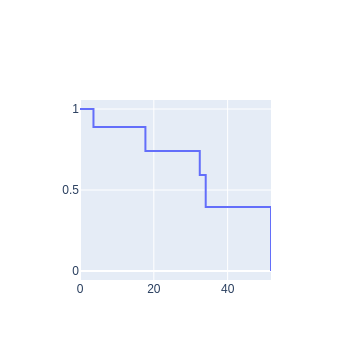

In [26]:
# Add the high-TMB survival curve

fig.add_trace(
    go.Scatter(
        x=kmf_high.survival_function_.index,
        y=kmf_high.survival_function_[
            "High TMB"
        ],
        mode="lines",
        line_shape="hv",
        name="High TMB",
        hovertemplate=(
            "Time: %{x:.1f} months"
            "<br>Survival probability: %{y:.3f}"
            "<extra></extra>"
        )
    )
)

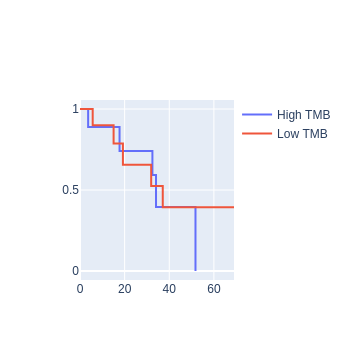

In [27]:
# Add the low-TMB survival curve 

fig.add_trace(
    go.Scatter(
        x=kmf_low.survival_function_.index,
        y=kmf_low.survival_function_[
            "Low TMB"
        ],
        mode="lines",
        line_shape="hv",
        name="Low TMB",
        hovertemplate=(
            "Time: %{x:.1f} months"
            "<br>Survival probability: %{y:.3f}"
            "<extra></extra>"
        )
    )
)

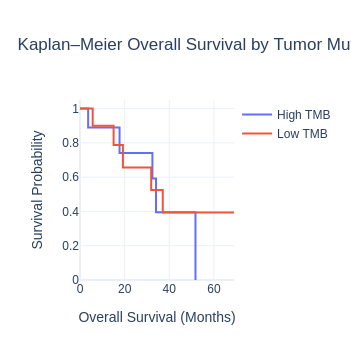

In [28]:
# Format and display the figure 

fig.update_layout(
    title=(
        "Kaplan–Meier Overall Survival "
        "by Tumor Mutational Burden"
    ),
    xaxis_title=(
        "Overall Survival (Months)"
    ),
    yaxis_title=(
        "Survival Probability"
    ),
    yaxis={
        "range": [0, 1.05]
    },
    hovermode="x unified",
    template="plotly_white"
)

fig.show()

# Add confidence intervals 

In [29]:
# Create a helper function 
def add_confidence_interval(
    figure,
    fitter,
    group_name
):
    confidence_interval = (
        fitter.confidence_interval_
    )

    figure.add_trace(
        go.Scatter(
            x=confidence_interval.index,
            y=confidence_interval.iloc[:, 1],
            mode="lines",
            line={"width": 0},
            showlegend=False,
            hoverinfo="skip"
        )
    )

    figure.add_trace(
        go.Scatter(
            x=confidence_interval.index,
            y=confidence_interval.iloc[:, 0],
            mode="lines",
            line={"width": 0},
            fill="tonexty",
            opacity=0.2,
            name=f"{group_name} 95% CI",
            hoverinfo="skip",
            showlegend=False
        )
    )

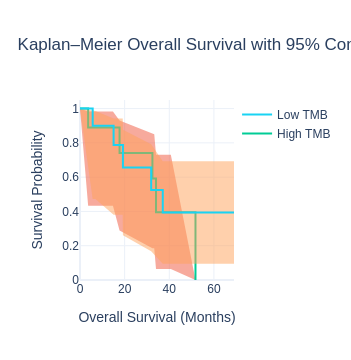

In [30]:
# Rebuild the figure with confidence intervals 

fig_ci = go.Figure()

add_confidence_interval(
    fig_ci,
    kmf_high,
    "High TMB"
)

fig_ci.add_trace(
    go.Scatter(
        x=kmf_high.survival_function_.index,
        y=kmf_high.survival_function_.iloc[:, 0],
        mode="lines",
        line_shape="hv",
        name="High TMB"
    )
)

add_confidence_interval(
    fig_ci,
    kmf_low,
    "Low TMB"
)

fig_ci.add_trace(
    go.Scatter(
        x=kmf_low.survival_function_.index,
        y=kmf_low.survival_function_.iloc[:, 0],
        mode="lines",
        line_shape="hv",
        name="Low TMB"
    )
)

fig_ci.update_layout(
    title=(
        "Kaplan–Meier Overall Survival "
        "with 95% Confidence Intervals"
    ),
    xaxis_title=(
        "Overall Survival (Months)"
    ),
    yaxis_title=(
        "Survival Probability"
    ),
    yaxis={
        "range": [0, 1.05]
    },
    template="plotly_white"
)

fig_ci.show()

# Perform the log-rank test 

In [31]:
logrank_results = logrank_test(
    high_tmb_df[
        "Overall Survival (Months)"
    ],
    low_tmb_df[
        "Overall Survival (Months)"
    ],
    event_observed_A=high_tmb_df[
        "Event"
    ],
    event_observed_B=low_tmb_df[
        "Event"
    ]
)

In [32]:
# Display the results 
print(
    "Log-rank test statistic:",
    round(
        logrank_results.test_statistic,
        3
    )
)

print(
    "Log-rank p-value:",
    round(
        logrank_results.p_value,
        4
    )
)

Log-rank test statistic: 0.072
Log-rank p-value: 0.7886


Interpretation:

* A p-value below 0.05 suggests evidence that the survival distributions differ.
* A p-value at or above 0.05 means the analysis does not provide sufficient evidence of a difference.
* A nonsignificant result does not prove that TMB has no relationship with survival, especially with a small sample size.

# Calculate median survival 

In [33]:
high_median_survival = (
    kmf_high.median_survival_time_
)

low_median_survival = (
    kmf_low.median_survival_time_
)

median_survival_table = pd.DataFrame({
    "TMB Group": [
        "High TMB",
        "Low TMB"
    ],
    "Patients": [
        len(high_tmb_df),
        len(low_tmb_df)
    ],
    "Deaths": [
        high_tmb_df["Event"].sum(),
        low_tmb_df["Event"].sum()
    ],
    "Median Survival Months": [
        high_median_survival,
        low_median_survival
    ]
})

median_survival_table

,TMB Group,Patients,Deaths,Median Survival Months
0,High TMB,9,5,34.060
1,Low TMB,10,5,37.085


If the estimated survival curve never falls to or below 0.50, the median survival may be reported as infinity. This means median survival was not reached during the observed follow-up period.

# Create a results summary 

In [34]:
results_summary = pd.DataFrame({
    "Analysis": [
        "Median TMB Kaplan-Meier"
    ],
    "TMB Cutoff": [
        median_tmb
    ],
    "High TMB Patients": [
        len(high_tmb_df)
    ],
    "Low TMB Patients": [
        len(low_tmb_df)
    ],
    "High TMB Deaths": [
        high_tmb_df["Event"].sum()
    ],
    "Low TMB Deaths": [
        low_tmb_df["Event"].sum()
    ],
    "Log-Rank Statistic": [
        logrank_results.test_statistic
    ],
    "Log-Rank p-value": [
        logrank_results.p_value
    ],
    "High TMB Median Survival": [
        high_median_survival
    ],
    "Low TMB Median Survival": [
        low_median_survival
    ]
})

results_summary

,Analysis,TMB Cutoff,High TMB Patients,Low TMB Patients,High TMB Deaths,Low TMB Deaths,Log-Rank Statistic,Log-Rank p-value,High TMB Median Survival,Low TMB Median Survival
0,Median TMB Kaplan-Meier,1.66287,9,10,5,5,0.071869,0.788635,34.06,37.085


# Compare quartile-based TMB groups 

In [35]:
# Create quartile categories 
survival_df["TMB Quartile"] = pd.qcut(
    survival_df[
        "TMB (nonsynonymous)"
    ],
    q=4,
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4"
    ],
    duplicates="drop"
)

survival_df[
    "TMB Quartile"
].value_counts().sort_index()

TMB Quartile
Q1    5
Q2    5
Q3    4
Q4    5
Name: count, dtype: int64

In [36]:
# Compare the lowest and highest quartiles 
quartile_df = survival_df[
    survival_df[
        "TMB Quartile"
    ].isin([
        "Q1",
        "Q4"
    ])
].copy()

q1_df = quartile_df[
    quartile_df["TMB Quartile"]
    == "Q1"
]

q4_df = quartile_df[
    quartile_df["TMB Quartile"]
    == "Q4"
]

In [37]:
# Run the log-rank test
quartile_logrank = logrank_test(
    q4_df[
        "Overall Survival (Months)"
    ],
    q1_df[
        "Overall Survival (Months)"
    ],
    event_observed_A=q4_df[
        "Event"
    ],
    event_observed_B=q1_df[
        "Event"
    ]
)

print(
    "Q4 versus Q1 log-rank p-value:",
    round(
        quartile_logrank.p_value,
        4
    )
)

Q4 versus Q1 log-rank p-value: 0.896


# Test a custom TMB cutoff 

In [38]:
custom_cutoff = 5.0

In [39]:
# Change this value to examine other biologically or clinically meaningful thresholds.

custom_df = survival_df.copy()

custom_df[
    "Custom TMB Group"
] = (
    custom_df[
        "TMB (nonsynonymous)"
    ] > custom_cutoff
).map({
    True: "High TMB",
    False: "Low TMB"
})

custom_df[
    "Custom TMB Group"
].value_counts()

Custom TMB Group
Low TMB     18
High TMB     1
Name: count, dtype: int64

In [40]:
# Separate the groups 
custom_high = custom_df[
    custom_df[
        "Custom TMB Group"
    ] == "High TMB"
]

custom_low = custom_df[
    custom_df[
        "Custom TMB Group"
    ] == "Low TMB"
]

In [41]:
# Only run the test when both groups contain patients:
if (
    len(custom_high) > 0
    and len(custom_low) > 0
):
    custom_logrank = logrank_test(
        custom_high[
            "Overall Survival (Months)"
        ],
        custom_low[
            "Overall Survival (Months)"
        ],
        event_observed_A=custom_high[
            "Event"
        ],
        event_observed_B=custom_low[
            "Event"
        ]
    )

    print(
        "Custom cutoff:",
        custom_cutoff
    )

    print(
        "Custom-cutoff p-value:",
        round(
            custom_logrank.p_value,
            4
        )
    )
else:
    print(
        "The custom cutoff produced an empty group."
    )

Custom cutoff: 5.0
Custom-cutoff p-value: 0.0


# Create a resuable survival-analysis function

In [42]:
def run_tmb_survival_analysis(
    data,
    cutoff
):
    analysis_data = data.copy()

    analysis_data[
        "TMB Group"
    ] = (
        analysis_data[
            "TMB (nonsynonymous)"
        ] > cutoff
    ).map({
        True: "High TMB",
        False: "Low TMB"
    })

    high_group = analysis_data[
        analysis_data[
            "TMB Group"
        ] == "High TMB"
    ]

    low_group = analysis_data[
        analysis_data[
            "TMB Group"
        ] == "Low TMB"
    ]

    if high_group.empty or low_group.empty:
        raise ValueError(
            "Both groups must contain at least one patient."
        )

    km_high = KaplanMeierFitter()
    km_low = KaplanMeierFitter()

    km_high.fit(
        high_group[
            "Overall Survival (Months)"
        ],
        event_observed=high_group[
            "Event"
        ],
        label="High TMB"
    )

    km_low.fit(
        low_group[
            "Overall Survival (Months)"
        ],
        event_observed=low_group[
            "Event"
        ],
        label="Low TMB"
    )

    test = logrank_test(
        high_group[
            "Overall Survival (Months)"
        ],
        low_group[
            "Overall Survival (Months)"
        ],
        event_observed_A=high_group[
            "Event"
        ],
        event_observed_B=low_group[
            "Event"
        ]
    )

    summary = pd.DataFrame({
        "TMB Group": [
            "High TMB",
            "Low TMB"
        ],
        "Patients": [
            len(high_group),
            len(low_group)
        ],
        "Deaths": [
            high_group["Event"].sum(),
            low_group["Event"].sum()
        ],
        "Median Survival": [
            km_high.median_survival_time_,
            km_low.median_survival_time_
        ]
    })

    return {
        "data": analysis_data,
        "high_fitter": km_high,
        "low_fitter": km_low,
        "logrank_statistic": (
            test.test_statistic
        ),
        "logrank_p_value": (
            test.p_value
        ),
        "summary": summary
    }

In [43]:
# Test the function

test_results = run_tmb_survival_analysis(
    survival_df,
    cutoff=median_tmb
)

test_results["summary"]

,TMB Group,Patients,Deaths,Median Survival
0,High TMB,9,5,34.060
1,Low TMB,10,5,37.085


In [44]:
print(
    test_results[
        "logrank_p_value"
    ]
)

0.7886345519772439


# Export the analysis dataset 

In [45]:
survival_df.to_csv(
    RESULTS_DIR
    / "patient_survival_analysis_data.tsv",
    sep="\t",
    index=False
)

# Export summary tables 

In [46]:
group_event_summary.to_csv(
    RESULTS_DIR
    / "tmb_group_summary.csv",
    index=False
)

median_survival_table.to_csv(
    RESULTS_DIR
    / "median_survival_summary.csv",
    index=False
)

results_summary.to_csv(
    RESULTS_DIR
    / "logrank_results.csv",
    index=False
)

# Export the Kaplan-Meier figure

In [47]:
fig_ci.write_html(
    RESULTS_DIR
    / "kaplan_meier_tmb.html"
)

# Conclusions

• Patient-level data were used so that each patient contributed one independent observation to the survival analysis.

• Tumor mutational burden was represented using the mean TMB across samples from each patient.

• Patients were initially divided into low- and high-TMB groups using the median patient-level TMB.

• Kaplan–Meier curves were used to estimate overall survival over time.

• A log-rank test was used to compare the survival distributions of the low- and high-TMB groups.

• Median survival estimates were calculated when the survival curves reached a probability of 0.50.

• Alternative grouping strategies, including quartile and custom TMB cutoffs, were examined as sensitivity analyses.

• Results must be interpreted cautiously because the small cohort size limits statistical power and may make the findings sensitive to the selected aggregation method and TMB cutoff.